# Non-uniform BC sensitivity test

This notebook tests how the model reacts when the discharge boundary conditions are changed at some of the 7 locations and not at all of them. The predictions of the modified scenarios are compared with the baseline event, and two held-out scenarios (`desync2` and `emptying_postpeak`) are compared with SFINCS.

In [2]:
import sys, os

try:
    import pyproj
    _proj_db = pyproj.datadir.get_data_dir()
    os.environ.setdefault('PROJ_DATA', _proj_db)
    os.environ.setdefault('PROJ_LIB',  _proj_db)
except Exception:
    pass

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config, get_CSI
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset, separate_multiscale_node_features
from utils.visualization import PlotRollout
from training.train import LightningTrainer, rollout_test_warmstart

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Load config, dataset, and checkpoint

In [3]:
CONFIG       = 'configs/config_best_sweep.yaml'   # architecture auto-detected per checkpoint; 4-scale mesh
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'   # held-out 1.0x event, 4-scale mesh
CHECKPOINT   = os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5')  # best_valloss (well-converged; see multiscale_loss notebook diagnostic)

exists = os.path.exists(CHECKPOINT)
size = f"{os.path.getsize(CHECKPOINT)/1e6:.1f} MB" if exists else 'MISSING'
print(f"checkpoint exists={exists!s:<6} {size:>10}  {CHECKPOINT}")

checkpoint exists=True       2.5 MB  c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_bcaugment.h5


In [4]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)
print('BC shape: ', temporal_test_dataset[0].BC.shape)  # [n_bc_locations, time]

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])
BC shape:  torch.Size([7, 3, 119])


In [5]:
def load_model_from_checkpoint(checkpoint_path):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features,
        num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'],
        device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model,
        'lr_info': config['lr_info'],
        'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(
        checkpoint_path, map_location=device, **plmodule_kwargs
    )
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


model, hid, K_list = load_model_from_checkpoint(CHECKPOINT)
print(f'Loaded model: hid={hid} K={K_list}')

Loaded model: hid=32 K=[1, 1, 1, 5, 4, 3, 2]


## BC location order and tributary selection

In [6]:
SRC_FILE = 'database/raw_datasets_ahr/Simulations/ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart/sfincs.src'
DIS_FILE = 'database/raw_datasets_ahr/Simulations/ahr_river_v03_Marg_additionalsrc_velocity_100m_cutpolygon_warmstart/sfincs.dis'

names = []
with open(SRC_FILE, encoding='latin-1') as f:
    for line in f:
        if line.strip():
            names.append(line.split('"')[1])

dis = np.loadtxt(DIS_FILE)
assert dis.shape[1] - 1 == len(names) == temporal_test_dataset[0].BC.shape[0], \
    'BC row count does not match sfincs.src — order assumption is unsafe, stop and investigate'

# Some source columns contain real NaNs that the proper parser (parse_dis_file in
# database/convert_sfincs_to_pkl_marg.py) interpolates over before they reach the model.
# Total volume (integral of Q over time) is the physically relevant quantity for identifying
# the main stem vs. tributaries — not the instantaneous mean, which is more sensitive to how the
# NaN gaps happen to be distributed in time. Interpolate over NaNs before integrating.
time_s = dis[:, 0]
volumes = []
for i in range(len(names)):
    col = dis[:, i + 1]
    valid = ~np.isnan(col)
    col_filled = np.interp(time_s, time_s[valid], col[valid])
    volumes.append(np.trapezoid(col_filled, time_s))  # m^3
volumes = np.array(volumes)

print(f"{'#':>2} {'name':<14} {'mean [m3/s]':>12} {'max [m3/s]':>11} {'#NaN':>6} {'volume [Mm3]':>13}")
for i, n in enumerate(names):
    col = dis[:, i + 1]
    print(f"{i:>2} {n:<14} {np.nanmean(col):>12.2f} {np.nanmax(col):>11.2f} {np.isnan(col).sum():>6} {volumes[i]/1e6:>13.2f}")

order = np.argsort(volumes)  # ascending: smallest total contributor first
MAIN_IDX = int(order[-1])
ZERO_IDX = [int(i) for i in order[:3]]     # 3 smallest by total volume
SMALLEST_IDX = int(order[0])

print(f"\nMain stem (largest volume): {names[MAIN_IDX]}")
print(f"Smallest tributaries (3 lowest volume): {[names[i] for i in ZERO_IDX]}")
print(f"Single smallest tributary: {names[SMALLEST_IDX]}")

 # name            mean [m3/s]  max [m3/s]   #NaN  volume [Mm3]
 0 Kreuzberg             11.90      152.25      0          5.15
 1 Denn                  14.85       69.15      0          6.42
 2 Kirmutscheid          69.95      455.00      0         30.27
 3 Muesch                17.85      126.53      0          7.72
 4 new1                  10.49      210.02      6          4.50
 5 Niederadenau          10.59      211.98      6          4.54
 6 new2                   5.09      101.79      6          2.18

Main stem (largest volume): Kirmutscheid
Smallest tributaries (3 lowest volume): ['new2', 'new1', 'Niederadenau']
Single smallest tributary: new2


## Run all BC scenarios

In [7]:
td = temporal_test_dataset[0]
node_ptr = test_dataset[0].node_ptr
gt_s0 = separate_multiscale_node_features(td.y.detach(), node_ptr)[0]
ws_gt = gt_s0[:, 0, :].clamp(min=0).sum(0)
t_pk = int(ws_gt.argmax())

n_bc = td.BC.shape[0]

def mult(base, overrides=()):
    """overrides: list of (index_list, value) pairs applied on top of a uniform `base`.
    Shape (n_bc, 1, 1) to broadcast against td.BC's [n_bc, previous_t, time] layout."""
    m = torch.full((n_bc, 1, 1), float(base))
    for idx, val in overrides:
        m[idx] = val
    return m

scenarios = {
    'baseline_1x':             mult(1.0),
    'tributaries_0x':          mult(1.0, [(ZERO_IDX,      0.0)]),
    'tributaries_2x':          mult(1.0, [(ZERO_IDX,      2.0)]),
    'mainstem_0x':             mult(1.0, [([MAIN_IDX],    0.0)]),
    'mainstem_2x':             mult(1.0, [([MAIN_IDX],    2.0)]),
    'only_mainstem':           mult(0.0, [([MAIN_IDX],    1.0)]),
    'only_smallest_tributary': mult(0.0, [([SMALLEST_IDX], 1.0)]),
}

rows = {}
preds = {}
for name, m in scenarios.items():
    tdf = td.clone()
    tdf.BC = td.BC * m
    with torch.no_grad():
        pred = rollout_test_warmstart(model, tdf, warmup_steps=0).detach()
    p_s0 = separate_multiscale_node_features(pred, node_ptr)[0]
    preds[name] = p_s0
    csi005 = get_CSI(p_s0, gt_s0, water_threshold=0.05).nanmean().item()
    csi03  = get_CSI(p_s0, gt_s0, water_threshold=0.30).nanmean().item()
    ws = p_s0[:, 0, :].clamp(min=0).sum(0)
    rows[name] = dict(csi005=csi005, csi03=csi03, ws_peak=float(ws[t_pk]), ws_end=float(ws[-1]),
                       maxWD=float(p_s0[:, 0, :].max()))

print(f"ground truth (1x): WDsum@peak={ws_gt[t_pk]:.0f}   WDsum@end={ws_gt[-1]:.0f}   maxWD={gt_s0[:,0,:].max():.2f} m\n")

b = rows['baseline_1x']
header = f"{'scenario':<26} {'CSI@0.05':>9} {'CSI@0.30':>9} {'WDsum@peak':>11} {'d_peak%':>8} {'WDsum@end':>10} {'d_end%':>7}"
print(header)
print('-' * len(header))
for name, r in rows.items():
    d_peak = (r['ws_peak'] / b['ws_peak'] - 1) * 100 if name != 'baseline_1x' else 0.0
    d_end  = (r['ws_end']  / b['ws_end']  - 1) * 100 if name != 'baseline_1x' else 0.0
    print(f"{name:<26} {r['csi005']:>9.4f} {r['csi03']:>9.4f} {r['ws_peak']:>11.0f} {d_peak:>+7.2f}% {r['ws_end']:>10.0f} {d_end:>+6.2f}%")

ground truth (1x): WDsum@peak=7767   WDsum@end=2519   maxWD=10.71 m

scenario                    CSI@0.05  CSI@0.30  WDsum@peak  d_peak%  WDsum@end  d_end%
--------------------------------------------------------------------------------------
baseline_1x                   0.8527    0.8988        8208   +0.00%       2966  +0.00%
tributaries_0x                0.8432    0.8892        6424  -21.73%       2781  -6.23%
tributaries_2x                0.8390    0.8902        8835   +7.64%       3342 +12.67%
mainstem_0x                   0.8606    0.8932        6255  -23.79%       2492 -15.99%
mainstem_2x                   0.8286    0.8781        9361  +14.05%       3475 +17.18%
only_mainstem                 0.8282    0.8577        3494  -57.43%       2478 -16.44%
only_smallest_tributary       0.8005    0.8013        1963  -76.08%       1585 -46.56%


### Spatial difference at the flood peak

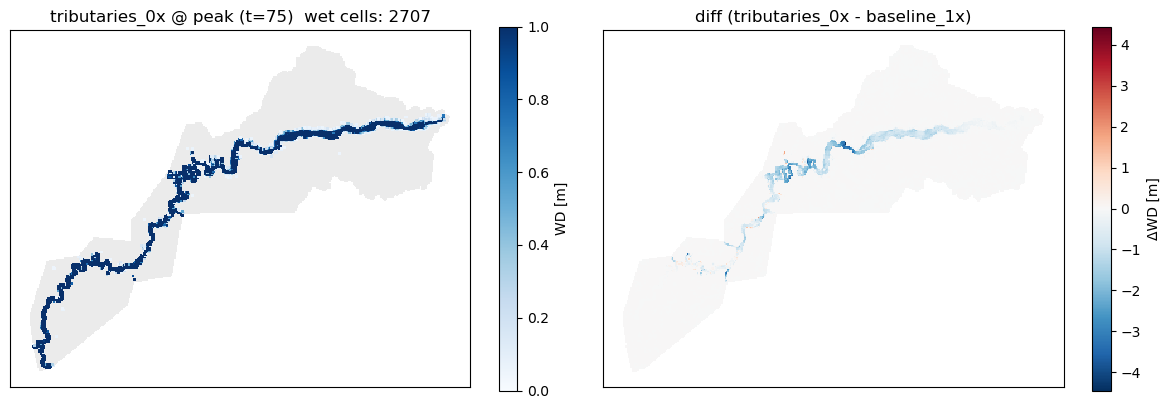

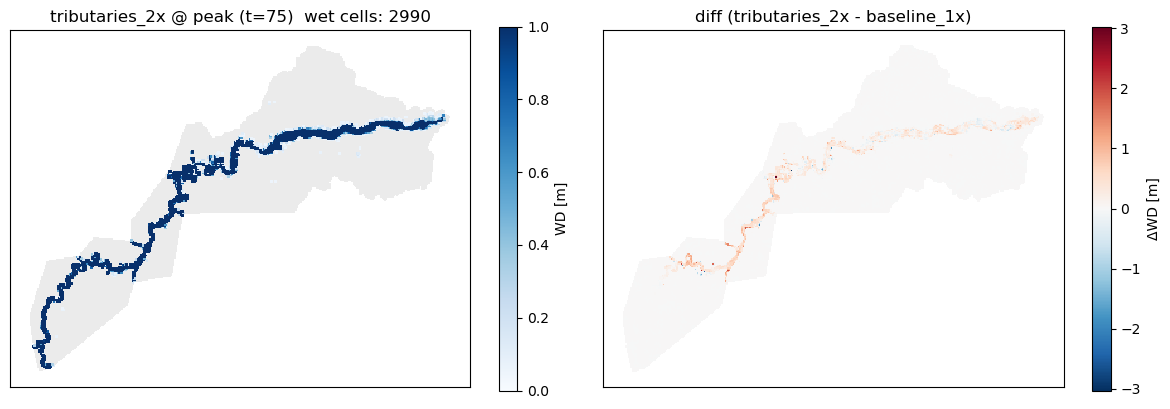

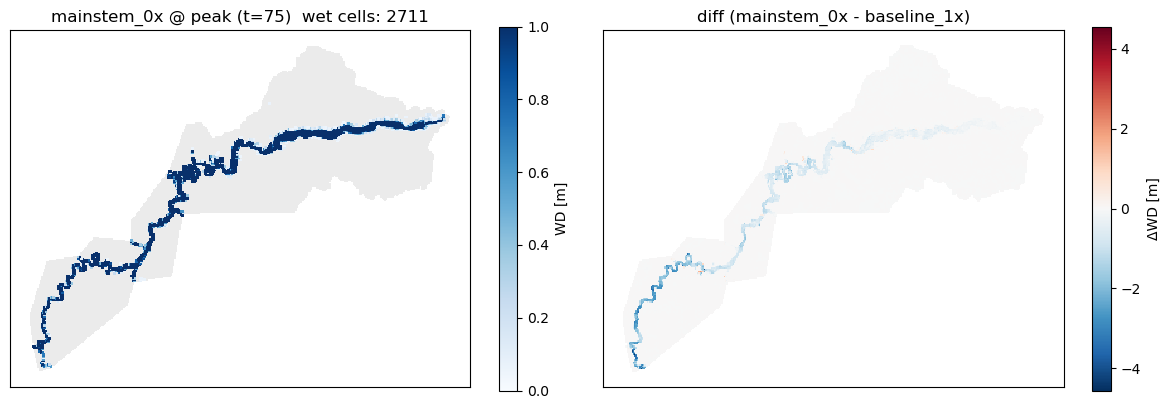

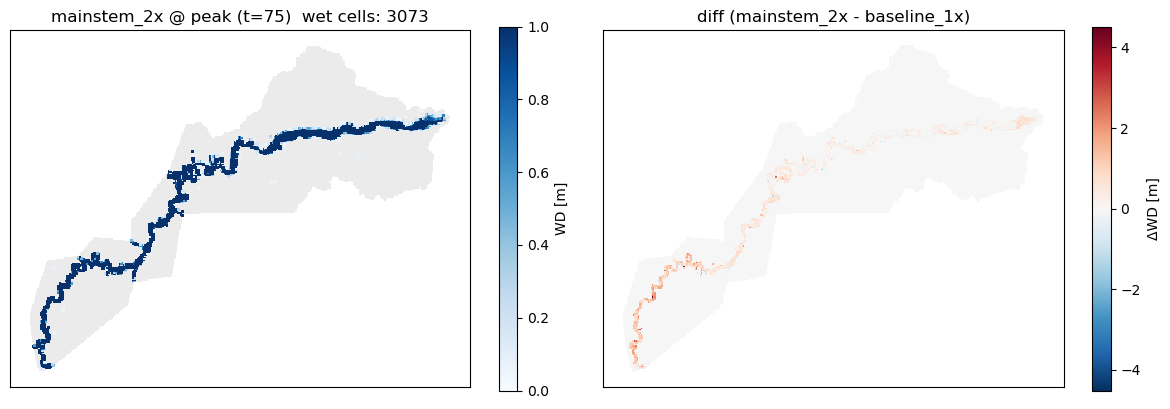

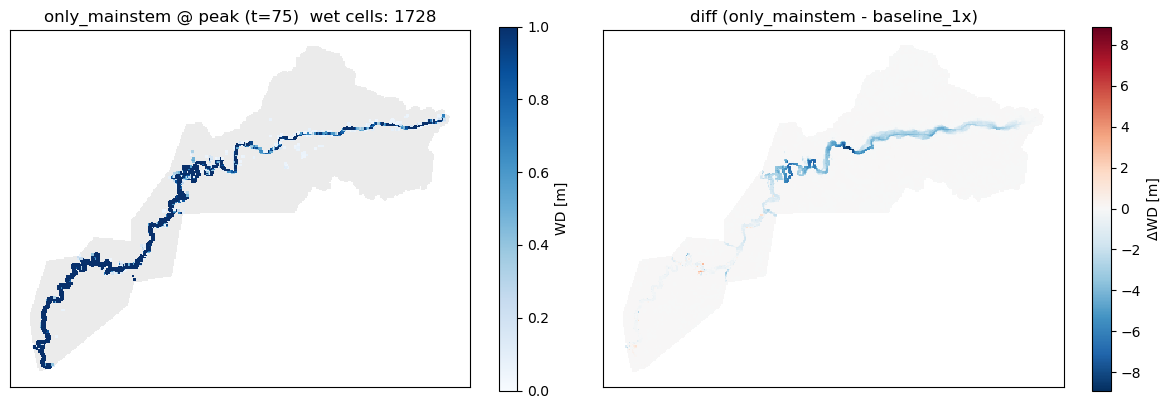

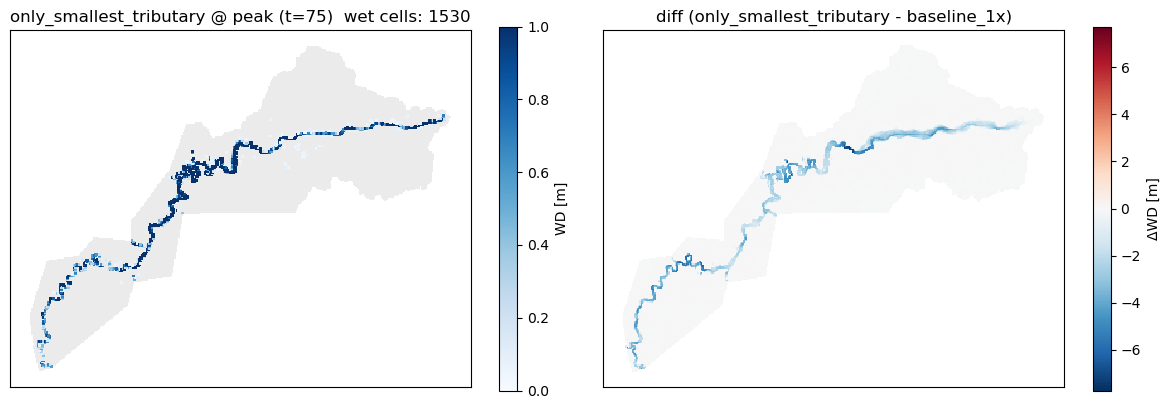

In [8]:
n_s0 = gt_s0.shape[0]
pos_s0 = np.asarray(test_dataset[0].mesh.face_xy)[:n_s0]
wd_base = preds['baseline_1x'][:, 0, t_pk].cpu().numpy()

for name, p_s0 in preds.items():
    if name == 'baseline_1x':
        continue
    wd = p_s0[:, 0, t_pk].cpu().numpy()
    diff = wd - wd_base

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    masked = np.where(wd > 0.05, wd, np.nan)
    axes[0].scatter(pos_s0[:, 0], pos_s0[:, 1], c='0.92', s=4, marker='s', linewidths=0)
    sc0 = axes[0].scatter(pos_s0[:, 0], pos_s0[:, 1], c=masked, cmap='Blues', vmin=0, vmax=1.0, s=4, marker='s', linewidths=0)
    axes[0].set_title(f'{name} @ peak (t={t_pk})  wet cells: {(wd > 0.05).sum()}')
    axes[0].set_aspect('equal'); axes[0].set_xticks([]); axes[0].set_yticks([])
    plt.colorbar(sc0, ax=axes[0], shrink=0.7, label='WD [m]')

    vmax = max(abs(diff.min()), abs(diff.max()), 1e-3)
    sc1 = axes[1].scatter(pos_s0[:, 0], pos_s0[:, 1], c=diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=4, marker='s', linewidths=0)
    axes[1].set_title(f'diff ({name} - baseline_1x)')
    axes[1].set_aspect('equal'); axes[1].set_xticks([]); axes[1].set_yticks([])
    plt.colorbar(sc1, ax=axes[1], shrink=0.7, label='ΔWD [m]')
    plt.tight_layout()
    plt.show()

## Per-location sensitivity ladder (leave-one-out)

In [9]:
ladder_rows = []
for i, n in enumerate(names):
    for factor, tag in [(0.0, 'zero'), (2.0, 'double')]:
        m = mult(1.0, [([i], factor)])
        tdf = td.clone()
        tdf.BC = td.BC * m
        with torch.no_grad():
            pred = rollout_test_warmstart(model, tdf, warmup_steps=0).detach()
        p_s0 = separate_multiscale_node_features(pred, node_ptr)[0]
        csi005 = get_CSI(p_s0, gt_s0, water_threshold=0.05).nanmean().item()
        ws = p_s0[:, 0, :].clamp(min=0).sum(0)
        d_peak = (float(ws[t_pk]) / b['ws_peak'] - 1) * 100
        d_end  = (float(ws[-1])  / b['ws_end']  - 1) * 100
        ladder_rows.append(dict(name=n, tag=tag, idx=i, csi005=csi005, d_csi005=csi005 - b['csi005'],
                                 d_peak=d_peak, d_end=d_end, volume_share=volumes[i] / volumes.sum() * 100))

print(f"{'location':<14} {'perturb':<7} {'CSI@0.05':>9} {'dCSI@0.05':>10} {'d_peak%':>8} {'d_end%':>7} {'vol_share%':>10}")
print('-' * 76)
for r in ladder_rows:
    print(f"{r['name']:<14} {r['tag']:<7} {r['csi005']:>9.4f} {r['d_csi005']:>+10.4f} "
          f"{r['d_peak']:>+7.2f}% {r['d_end']:>+6.2f}% {r['volume_share']:>9.2f}%")

location       perturb  CSI@0.05  dCSI@0.05  d_peak%  d_end% vol_share%
----------------------------------------------------------------------------
Kreuzberg      zero       0.8477    -0.0051  -18.01%  -8.45%      8.47%
Kreuzberg      double     0.8416    -0.0111   +5.69%  +6.52%      8.47%
Denn           zero       0.8553    +0.0026  -12.37%  -6.46%     10.57%
Denn           double     0.8392    -0.0135   +2.13%  +5.67%     10.57%
Kirmutscheid   zero       0.8606    +0.0078  -23.79% -15.99%     49.79%
Kirmutscheid   double     0.8286    -0.0241  +14.05% +17.18%     49.79%
Muesch         zero       0.8581    +0.0054  -10.78%  -2.73%     12.71%
Muesch         double     0.8401    -0.0126   +4.54%  +6.85%     12.71%
new1           zero       0.8511    -0.0016   -5.12%  -0.50%      7.40%
new1           double     0.8486    -0.0041   +4.66%  +2.99%      7.40%
Niederadenau   zero       0.8482    -0.0045   -7.76%  -1.72%      7.47%
Niederadenau   double     0.8488    -0.0039   +4.20%  +3.63

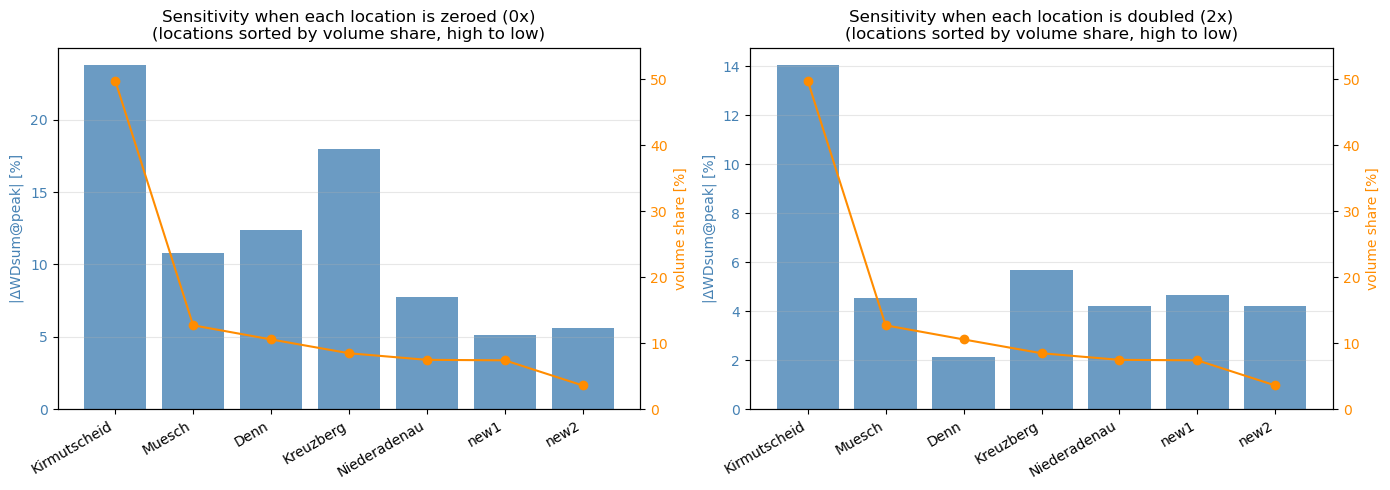

Reading this: bars (model's response) should roughly track the orange line (actual physical
contribution). A location with a tall bar but a low orange dot (or vice versa) is a named
location where the model over- or under-weights that BC relative to its real contribution.


In [10]:
sort_order = np.argsort(volumes)[::-1]  # descending physical volume share
plot_names = [names[i] for i in sort_order]
vol_share_sorted = volumes[sort_order] / volumes.sum() * 100

def get_d_peak(idx, tag):
    return next(r['d_peak'] for r in ladder_rows if r['idx'] == idx and r['tag'] == tag)

zero_d_peak   = [abs(get_d_peak(i, 'zero'))   for i in sort_order]
double_d_peak = [abs(get_d_peak(i, 'double')) for i in sort_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(plot_names))
for ax, vals, title in zip(axes, [zero_d_peak, double_d_peak], ['zeroed (0x)', 'doubled (2x)']):
    ax2 = ax.twinx()
    ax.bar(x, vals, color='steelblue', alpha=0.8)
    ax2.plot(x, vol_share_sorted, 'o-', color='darkorange')
    # Force both axes to start at 0 - twinx() auto-scales the line plot independently
    # from the bars, and by default pads below 0, making the two curves' zero points
    # not line up (the orange dot's height stops being visually comparable to the bars).
    ax.set_ylim(0, None)
    ax2.set_ylim(0, vol_share_sorted.max() * 1.1)
    ax.set_xticks(x); ax.set_xticklabels(plot_names, rotation=30, ha='right')
    ax.set_ylabel('|ΔWDsum@peak| [%]', color='steelblue')
    ax2.set_ylabel('volume share [%]', color='darkorange')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax.set_title(f'Sensitivity when each location is {title}\n(locations sorted by volume share, high to low)')
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Reading this: bars (model's response) should roughly track the orange line (actual physical\n"
      "contribution). A location with a tall bar but a low orange dot (or vice versa) is a named\n"
      "location where the model over- or under-weights that BC relative to its real contribution.")

## Testing on complete drainage and varying time lag non uniformly between BC

In [11]:
def evaluate_new_scenario(dataset_name):
    """Build a test dataset for a different SFINCS run and evaluate it with the already-loaded model."""
    cfg_s = read_config(CONFIG)
    cfg_s['dataset_parameters']['test_dataset_name']  = dataset_name
    cfg_s['dataset_parameters']['train_dataset_name'] = dataset_name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg_s, reinit=True)
    fix_dict_in_config(wandb)
    config_s = wandb.config

    _, _, test_dataset_s, scalers_s = create_model_dataset(
        scalers=config_s.scalers, device=device,
        **config_s.dataset_parameters, **config_s.selected_node_features, **config_s.selected_edge_features)
    ttdp_s = get_temporal_test_dataset_parameters(config_s, config_s.temporal_dataset_parameters)

    pr = PlotRollout(model, test_dataset_s[0], scalers=scalers_s, warmup_steps=0, **ttdp_s)
    return pr, test_dataset_s


DESYNC2_NAME = 'ahr_river_v03_marg_desync2_additionalsrc_velocity_100m_warmstart'
pr_desync2, test_dataset_desync2 = evaluate_new_scenario(DESYNC2_NAME)

rl = pr_desync2._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_wd_desync2 = rl[0].item() if rl.ndim > 0 else rl.item()
csi005_desync2 = pr_desync2._get_CSI(water_threshold=0.05).nanmean().item()
csi03_desync2  = pr_desync2._get_CSI(water_threshold=0.30).nanmean().item()

print('desync2 (held-out, direction-flipped all-locations timing shift):')
print(f'  RMSE_WD={rmse_wd_desync2:.4f}  CSI@0.05={csi005_desync2:.4f}  CSI@0.30={csi03_desync2:.4f}')
print(f"  for context, the same model's CSI on the training-distribution 1x event: "
      f"CSI@0.05={b['csi005']:.4f}  CSI@0.30={b['csi03']:.4f}  (RMSE not computed for that scenario "
      f"in this notebook — see visualize_finetuned_fixed_gt_multisim_multiscale_loss.ipynb: RMSE_WD=0.1304)")

The validation dataset you are using is the training one. Careful!
desync2 (held-out, direction-flipped all-locations timing shift):
  RMSE_WD=0.1453  CSI@0.05=0.8184  CSI@0.30=0.8647
  for context, the same model's CSI on the training-distribution 1x event: CSI@0.05=0.8527  CSI@0.30=0.8988  (RMSE not computed for that scenario in this notebook — see visualize_finetuned_fixed_gt_multisim_multiscale_loss.ipynb: RMSE_WD=0.1304)


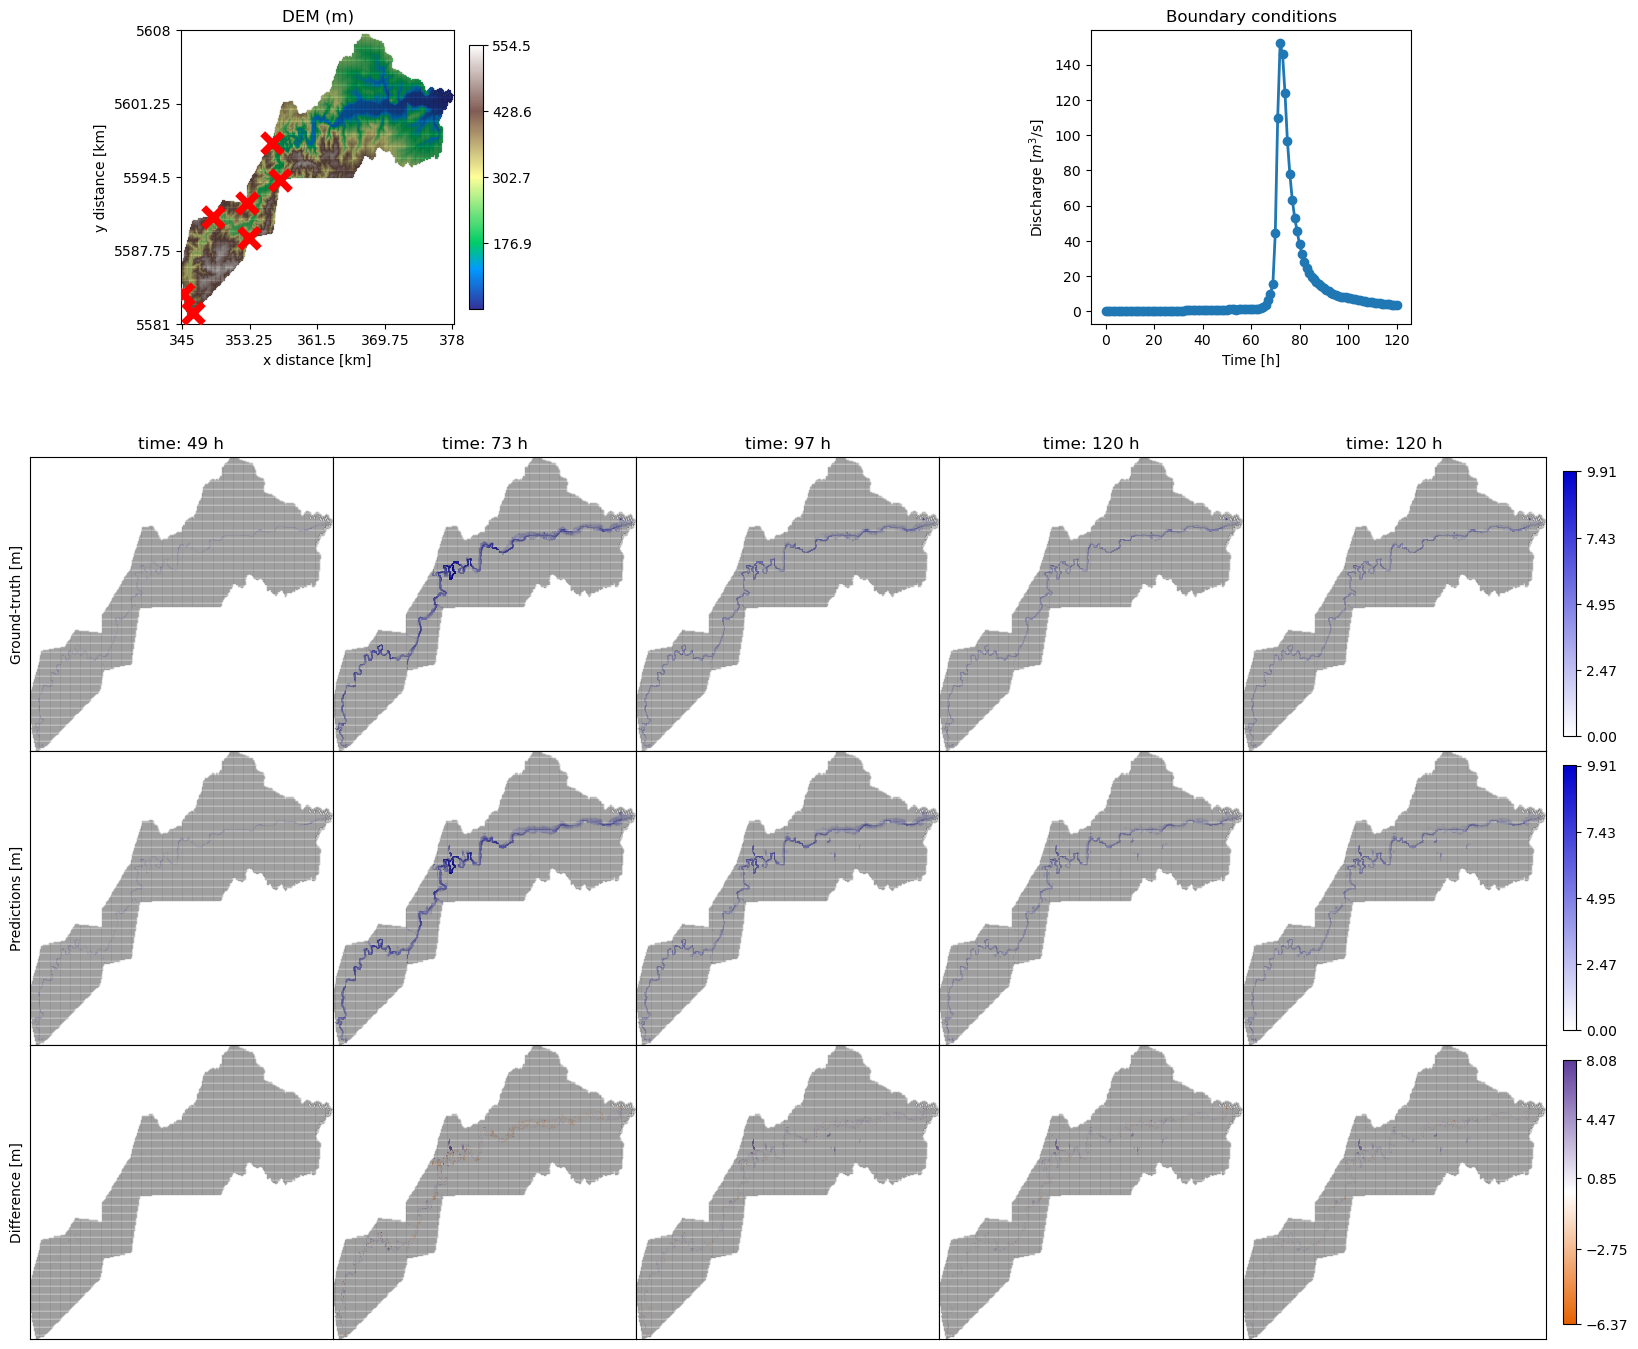

In [12]:
n_steps_desync2 = pr_desync2.real_rollout.shape[-1]
plot_times = [48, 72, 96, n_steps_desync2 - 1]
pr_desync2.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()

### Catchment emptying from post-peak

Plotting `WDsum` over the full rollout, predicted vs. real, rather than just RMSE/CSI at
one timestep.

The validation dataset you are using is the training one. Careful!
emptying_postpeak (held-out, draining from flood-peak state, all discharge = 0):
  RMSE_WD=0.2591  CSI@0.05=0.2215


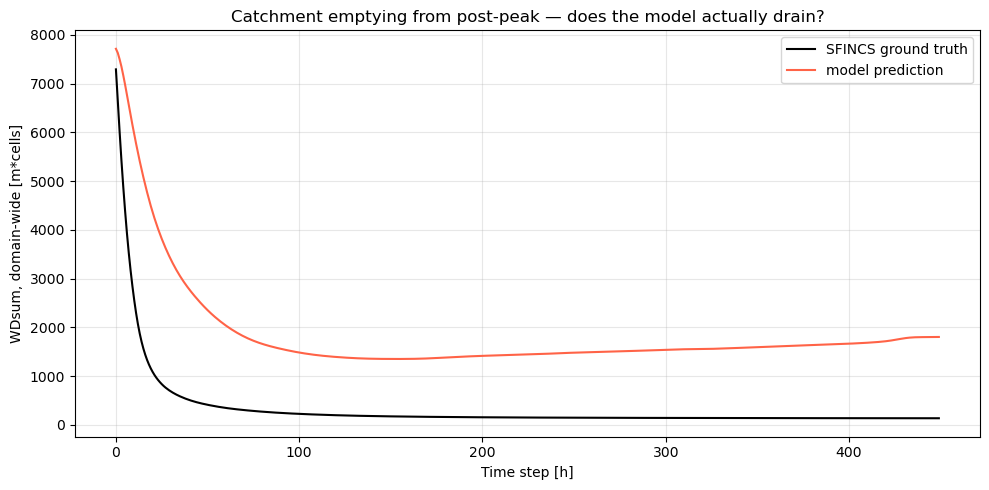

real:      starts=7295  ends=136  (1.9% of initial remains)
predicted: starts=7717  ends=1804  (23.4% of initial remains)


In [13]:
EMPTYING_NAME = 'ahr_river_v03_marg_emptying_postpeak_additionalsrc_velocity_100m_warmstart'
pr_emptying, test_dataset_emptying = evaluate_new_scenario(EMPTYING_NAME)

rl = pr_emptying._get_rollout_loss(type_loss='RMSE').mean(0)
rmse_wd_emptying = rl[0].item() if rl.ndim > 0 else rl.item()
csi005_emptying = pr_emptying._get_CSI(water_threshold=0.05).nanmean().item()

print('emptying_postpeak (held-out, draining from flood-peak state, all discharge = 0):')
print(f'  RMSE_WD={rmse_wd_emptying:.4f}  CSI@0.05={csi005_emptying:.4f}')

real_ws = pr_emptying._real_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()
pred_ws = pr_emptying._predicted_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(real_ws, label='SFINCS ground truth', color='k')
ax.plot(pred_ws, label='model prediction', color='tomato')
ax.set_xlabel('Time step [h]')
ax.set_ylabel('WDsum, domain-wide [m*cells]')
ax.set_title('Catchment emptying from post-peak — does the model actually drain?')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"real:      starts={real_ws[0]:.0f}  ends={real_ws[-1]:.0f}  ({real_ws[-1] / real_ws[0] * 100:.1f}% of initial remains)")
print(f"predicted: starts={pred_ws[0]:.0f}  ends={pred_ws[-1]:.0f}  ({pred_ws[-1] / pred_ws[0] * 100:.1f}% of initial remains)")

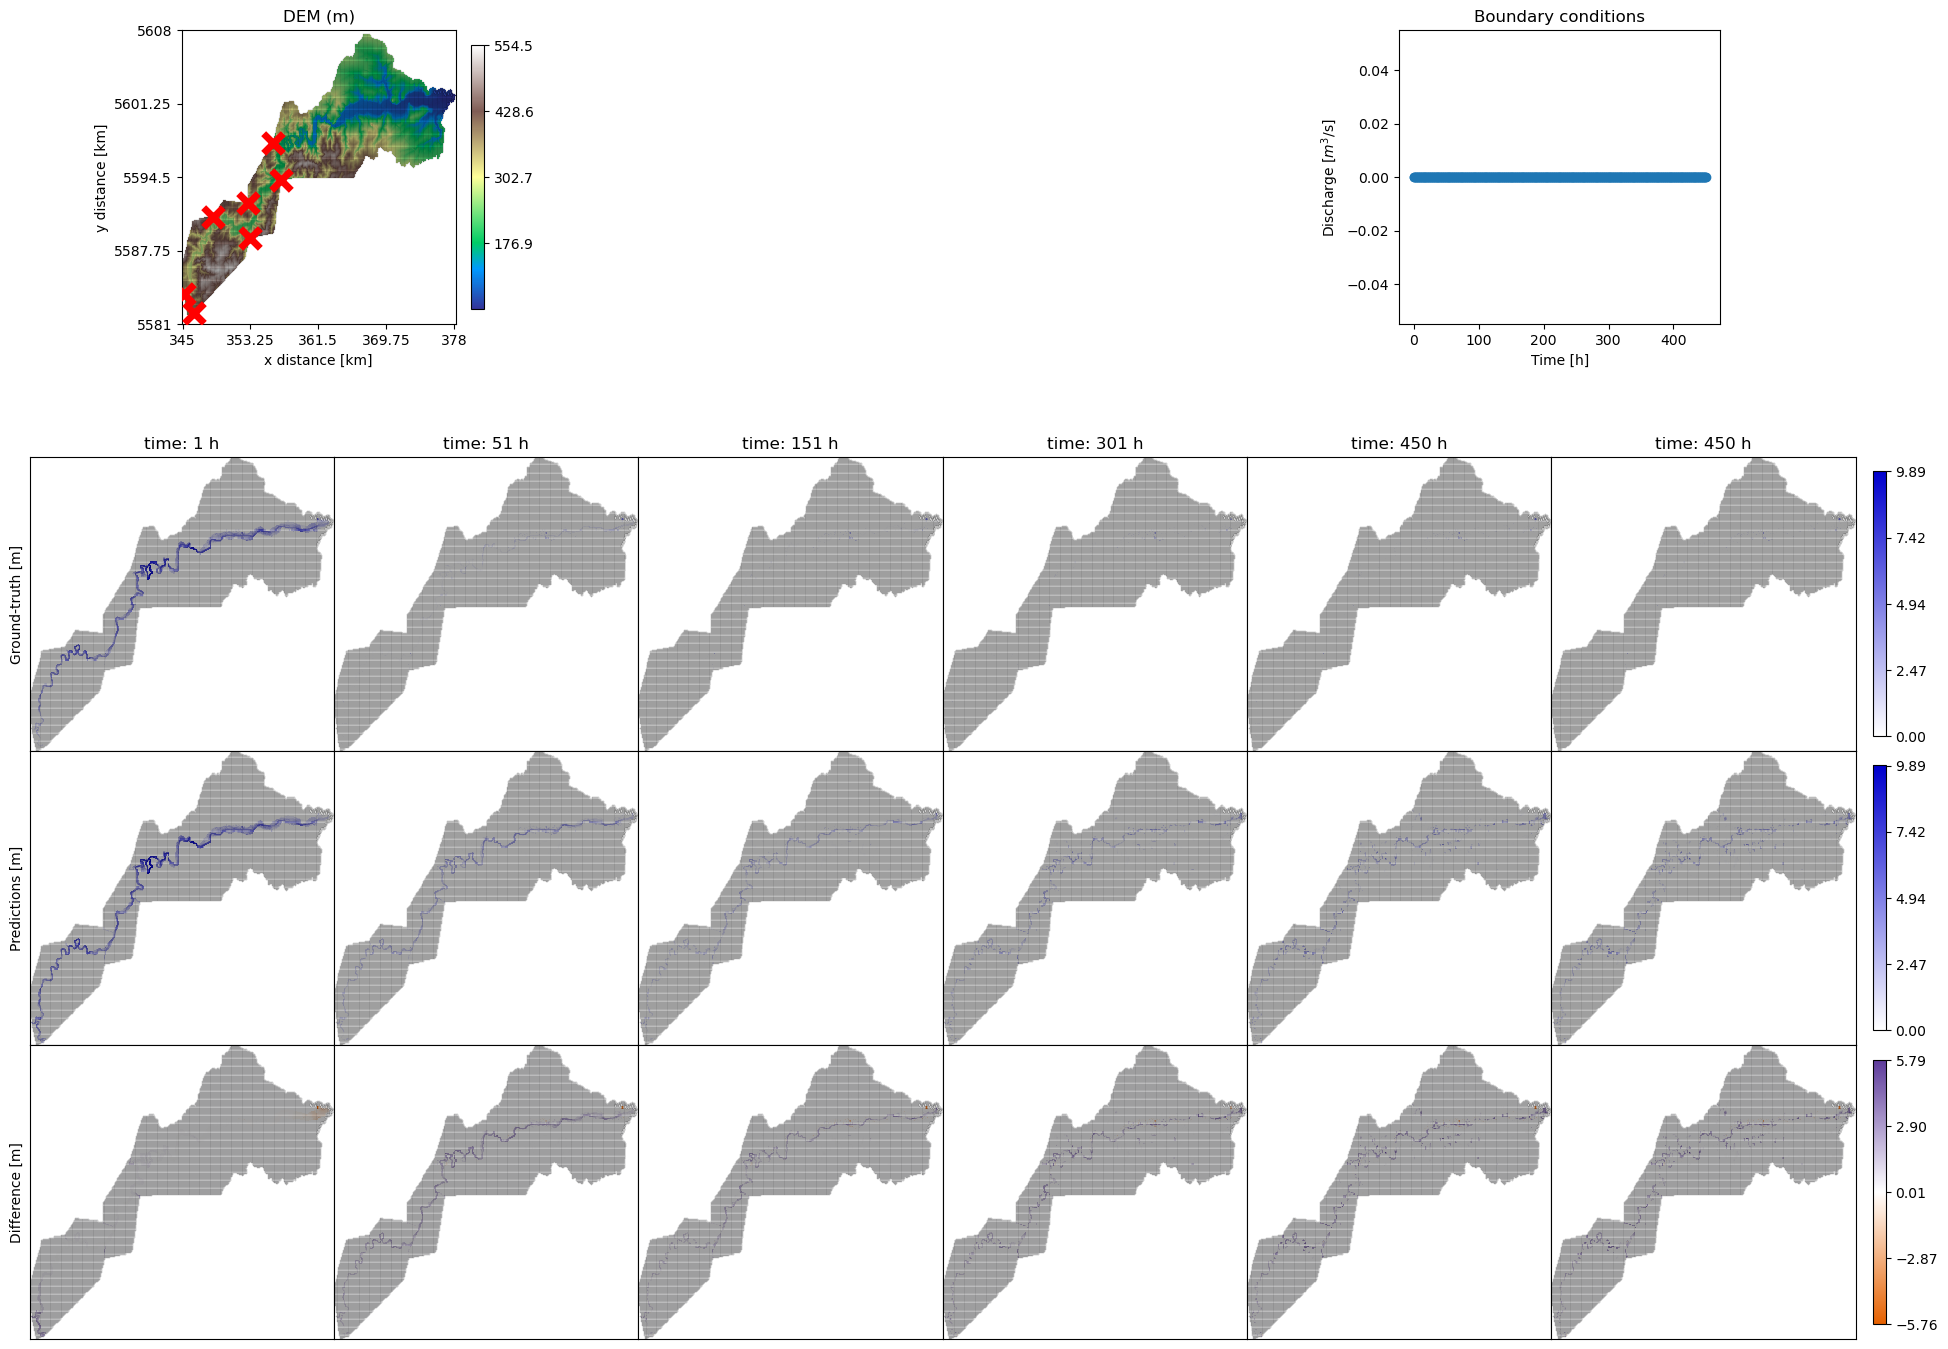

In [14]:
n_steps_emptying = pr_emptying.real_rollout.shape[-1]
plot_times = [0, 50, 150, 300, 449]  # spread across the ~450-step drain, same style as desync2
pr_emptying.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()

## Real ground truth for all 7 non-uniform scenarios: flood-peak timing / residence-time check

In [15]:
# --- CELL B (code) ---
TWENTYSIM_GT_NAMES = {
    'baseline_1x':             'ahr_river_v03_marg_baseline_1x_additionalsrc_velocity_100m_warmstart',
    'tributaries_0x':          'ahr_river_v03_marg_tributaries_0x_additionalsrc_velocity_100m_warmstart',
    'tributaries_2x':          'ahr_river_v03_marg_tributaries_2x_additionalsrc_velocity_100m_warmstart',
    'mainstem_0x':             'ahr_river_v03_marg_mainstem_0x_additionalsrc_velocity_100m_warmstart',
    'mainstem_2x':             'ahr_river_v03_marg_mainstem_2x_additionalsrc_velocity_100m_warmstart',
    'only_mainstem':           'ahr_river_v03_marg_only_mainstem_additionalsrc_velocity_100m_warmstart',
    'only_smallest_tributary': 'ahr_river_v03_marg_only_smallest_tributary_additionalsrc_velocity_100m_warmstart',
}

twentysim_gt = {}
for name, dataset_name in TWENTYSIM_GT_NAMES.items():
    pr_s, _ = evaluate_new_scenario(dataset_name)

    real_ws_s = pr_s._real_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()
    pred_ws_s = pr_s._predicted_rollout_s0[:, 0, :].clamp(min=0).sum(0).cpu().numpy()
    t_pk_real = int(real_ws_s.argmax())
    t_pk_pred = int(pred_ws_s.argmax())

    rl_s = pr_s._get_rollout_loss(type_loss='RMSE').mean(0)
    rmse_wd_s = rl_s[0].item() if rl_s.ndim > 0 else rl_s.item()
    csi005_s = pr_s._get_CSI(water_threshold=0.05).nanmean().item()
    csi03_s  = pr_s._get_CSI(water_threshold=0.30).nanmean().item()

    twentysim_gt[name] = dict(
        pr=pr_s, real_ws=real_ws_s, pred_ws=pred_ws_s,
        t_pk_real=t_pk_real, t_pk_pred=t_pk_pred, lag_h=t_pk_pred - t_pk_real,
        real_peak=float(real_ws_s[t_pk_real]), pred_peak=float(pred_ws_s[t_pk_pred]),
        rmse_wd=rmse_wd_s, csi005=csi005_s, csi03=csi03_s,
    )

header = (f"{'scenario':<26} {'t_pk real':>9} {'t_pk pred':>9} {'lag [h]':>8} "
          f"{'real peak':>10} {'pred peak':>10} {'d_peak%':>8} {'RMSE_WD':>8} {'CSI@0.05':>9} {'CSI@0.30':>9}")
print(header)
print('-' * len(header))
for name, r in twentysim_gt.items():
    d_peak = (r['pred_peak'] / r['real_peak'] - 1) * 100
    print(f"{name:<26} {r['t_pk_real']:>9d} {r['t_pk_pred']:>9d} {r['lag_h']:>+8d} "
          f"{r['real_peak']:>10.0f} {r['pred_peak']:>10.0f} {d_peak:>+7.2f}% "
          f"{r['rmse_wd']:>8.4f} {r['csi005']:>9.4f} {r['csi03']:>9.4f}")

lags = np.array([r['lag_h'] for r in twentysim_gt.values()])
print(f"\nlag [h] across scenarios: mean={lags.mean():+.1f}  std={lags.std():.1f}  "
      f"range=[{lags.min():+d}, {lags.max():+d}]")


The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
The validation dataset you are using is the training one. Careful!
scenario                   t_pk real t_pk pred  lag [h]  real peak  pred peak  d_peak%  RMSE_WD  CSI@0.05  CSI@0.30
-------------------------------------------------------------------------------------------------------------------
baseline_1x                       75        75       +0       7767       8940  +15.10%   0.1288    0.8334    0.8822
tributaries_0x                    77        76       -1       6650       7555  +13.60%   0.1190    0.8330    0.8835
tributaries_2x                    75        75       +0       8920 

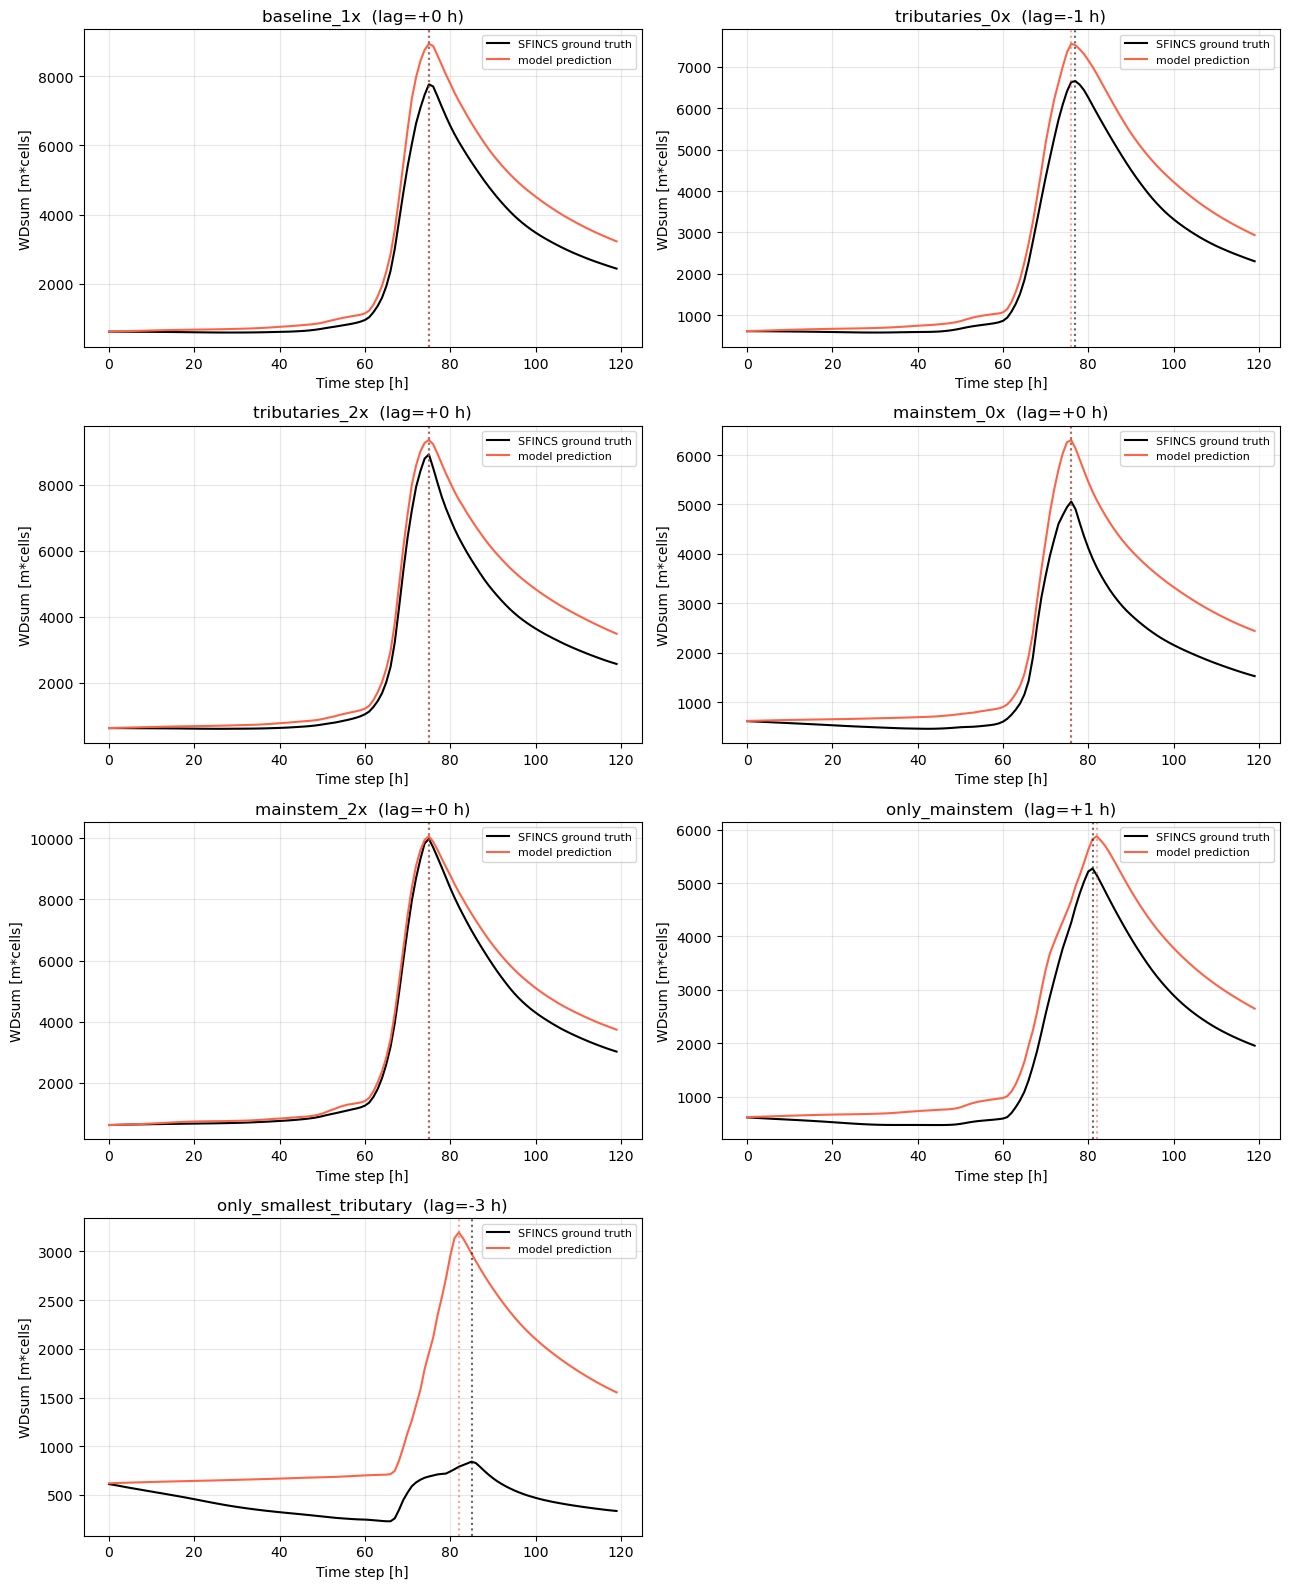

lag [h] across scenarios: mean=-0.4  std=1.2  range=[-3, +1]
A lag that's consistently the same sign/magnitude across scenarios (rather than scattered around 0) points to a systematic water-residence-time bias, not a per-scenario accuracy issue.


In [18]:
fig, axes = plt.subplots(4, 2, figsize=(13, 16), sharex=False)
for ax, (name, r) in zip(axes.flat, twentysim_gt.items()):
    ax.plot(r['real_ws'], label='SFINCS ground truth', color='k')
    ax.plot(r['pred_ws'], label='model prediction', color='tomato')
    ax.axvline(r['t_pk_real'], color='k', ls=':', alpha=0.6)
    ax.axvline(r['t_pk_pred'], color='tomato', ls=':', alpha=0.6)
    ax.set_title(f"{name}  (lag={r['lag_h']:+d} h)")
    ax.set_xlabel('Time step [h]')
    ax.set_ylabel('WDsum [m*cells]')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

lags = np.array([r['lag_h'] for r in twentysim_gt.values()])
print(f"lag [h] across scenarios: mean={lags.mean():+.1f}  std={lags.std():.1f}  "
      f"range=[{lags.min():+d}, {lags.max():+d}]")
print("A lag that's consistently the same sign/magnitude across scenarios (rather than scattered "
      "around 0) points to a systematic water-residence-time bias, not a per-scenario accuracy issue.")
